In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast

In [ ]:
df = pd.read_csv('../concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')

/tmp/ipykernel_56912/3667309216.py:1: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('concatenacao/dataset_concat2.0_tratado_Gustavo_e_Ivan.csv', sep=';')


In [19]:
# Glossário:
# - título: titulo do projeto
# - nome_orientador: nome do orientador do projeto (apenas em tccs)
# - nivel: nivel acadêmico (graduação, mestrado, etc)
# - ano: ano de relevância do projeto
# - classificação: se é tcc ou pesquisa
# - unidade: unidade acadêmica responsável pelo projeto
# - palavras_chave: palavras chaves do projeto
# - data_inicio: data de inicio do projeto
# - data_fim: data de finalização do projeto
# - situacao: situação de andamento do projeto (finalizado, em andamento, etc)
# - tipo_projeto: interno ou externo
# - linha_pesquisa: linha de pesquisa (somente projetos de pesquisa)
# - categoria: categoria do projeto (se é monografia, artigo, pesquisa, seminário, etc)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91964 entries, 0 to 91963
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   titulo                  91964 non-null  object 
 1   nome_orientador         77906 non-null  object 
 2   nivel                   91964 non-null  object 
 3   ano                     91964 non-null  float64
 4   classificacao           91964 non-null  object 
 5   unidade                 91624 non-null  object 
 6   palavras_chave          13836 non-null  object 
 7   data_inicio             91961 non-null  object 
 8   data_fim                91733 non-null  object 
 9   situacao                91964 non-null  object 
 10  tipo_projeto            91964 non-null  object 
 11  linha_pesquisa          13611 non-null  object 
 12  area_conhecimento_cnpq  13744 non-null  object 
 13  categoria               74254 non-null  object 
dtypes: float64(1), object(13)
memory usage

In [20]:
df['data_inicio'] = pd.to_datetime(df['data_inicio'], errors='coerce')
df['data_fim'] = pd.to_datetime(df['data_fim'], errors='coerce')

df['duracao'] = np.nan
mask_pesquisa = df['classificacao'] == 'pesquisa'
df.loc[mask_pesquisa, 'duracao'] = (df.loc[mask_pesquisa, 'data_fim'] - df.loc[mask_pesquisa, 'data_inicio']).dt.days

In [ ]:
plt.style.use('default')
sns.set_palette("husl")

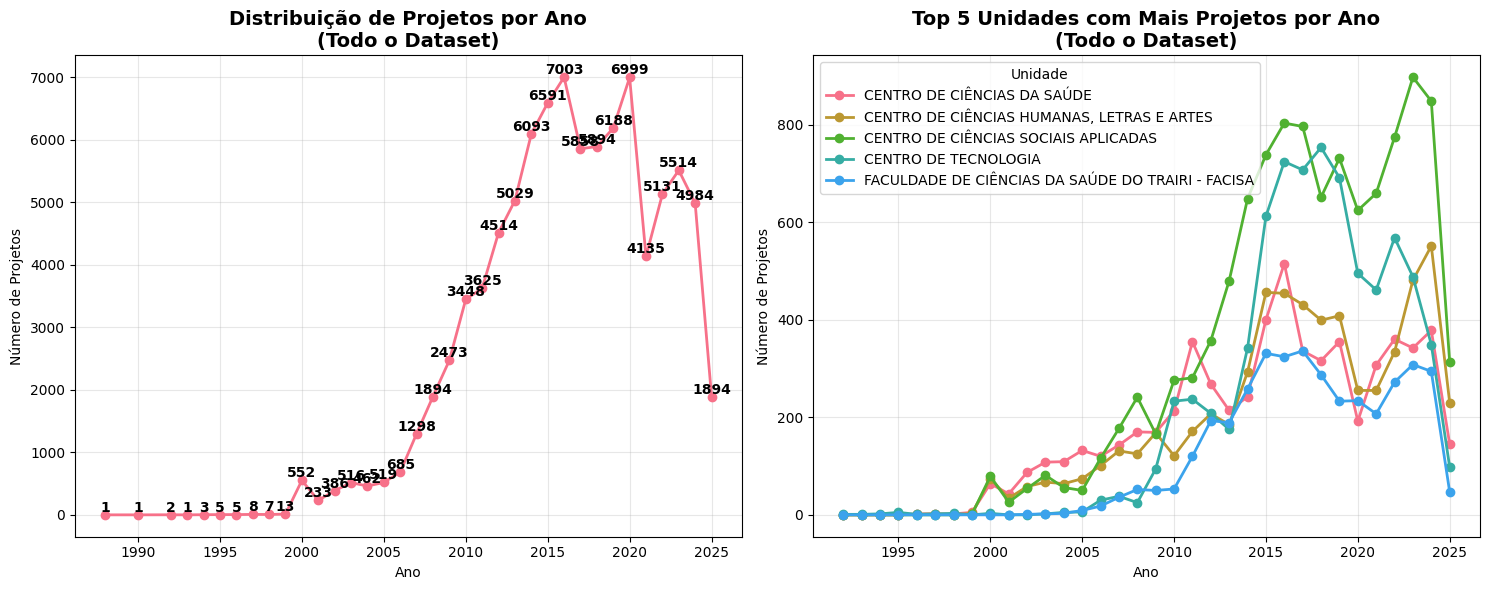

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1.1 Distribuição de projetos por ano (Geral)
projetos_por_ano_geral = df.groupby('ano').size()
axes[0].plot(projetos_por_ano_geral.index, projetos_por_ano_geral.values, 
             marker='o', linewidth=2, markersize=6)
axes[0].set_title('Distribuição de Projetos por Ano\n(Todo o Dataset)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Número de Projetos')
axes[0].grid(True, alpha=0.3)

# Adicionar valores nos pontos
for ano, count in projetos_por_ano_geral.items():
    axes[0].text(ano, count, f'{count}', ha='center', va='bottom', fontweight='bold')

# 1.2 Top 3 unidades com mais projetos por ano (Geral)
# Encontrar as top 3 unidades no geral
top3_unidades_geral = df['unidade'].value_counts().head(5).index

# Agrupar por ano e unidade para as top 3
top3_por_ano = df[df['unidade'].isin(top3_unidades_geral)].groupby(['ano', 'unidade']).size().unstack(fill_value=0)

top3_por_ano.plot(kind='line', marker='o', ax=axes[1], linewidth=2, markersize=6)
axes[1].set_title('Top 5 Unidades com Mais Projetos por Ano\n(Todo o Dataset)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Número de Projetos')
axes[1].grid(True, alpha=0.3)
axes[1].legend(title='Unidade')

plt.tight_layout()
plt.show()

Total de projetos de pesquisa: 14058


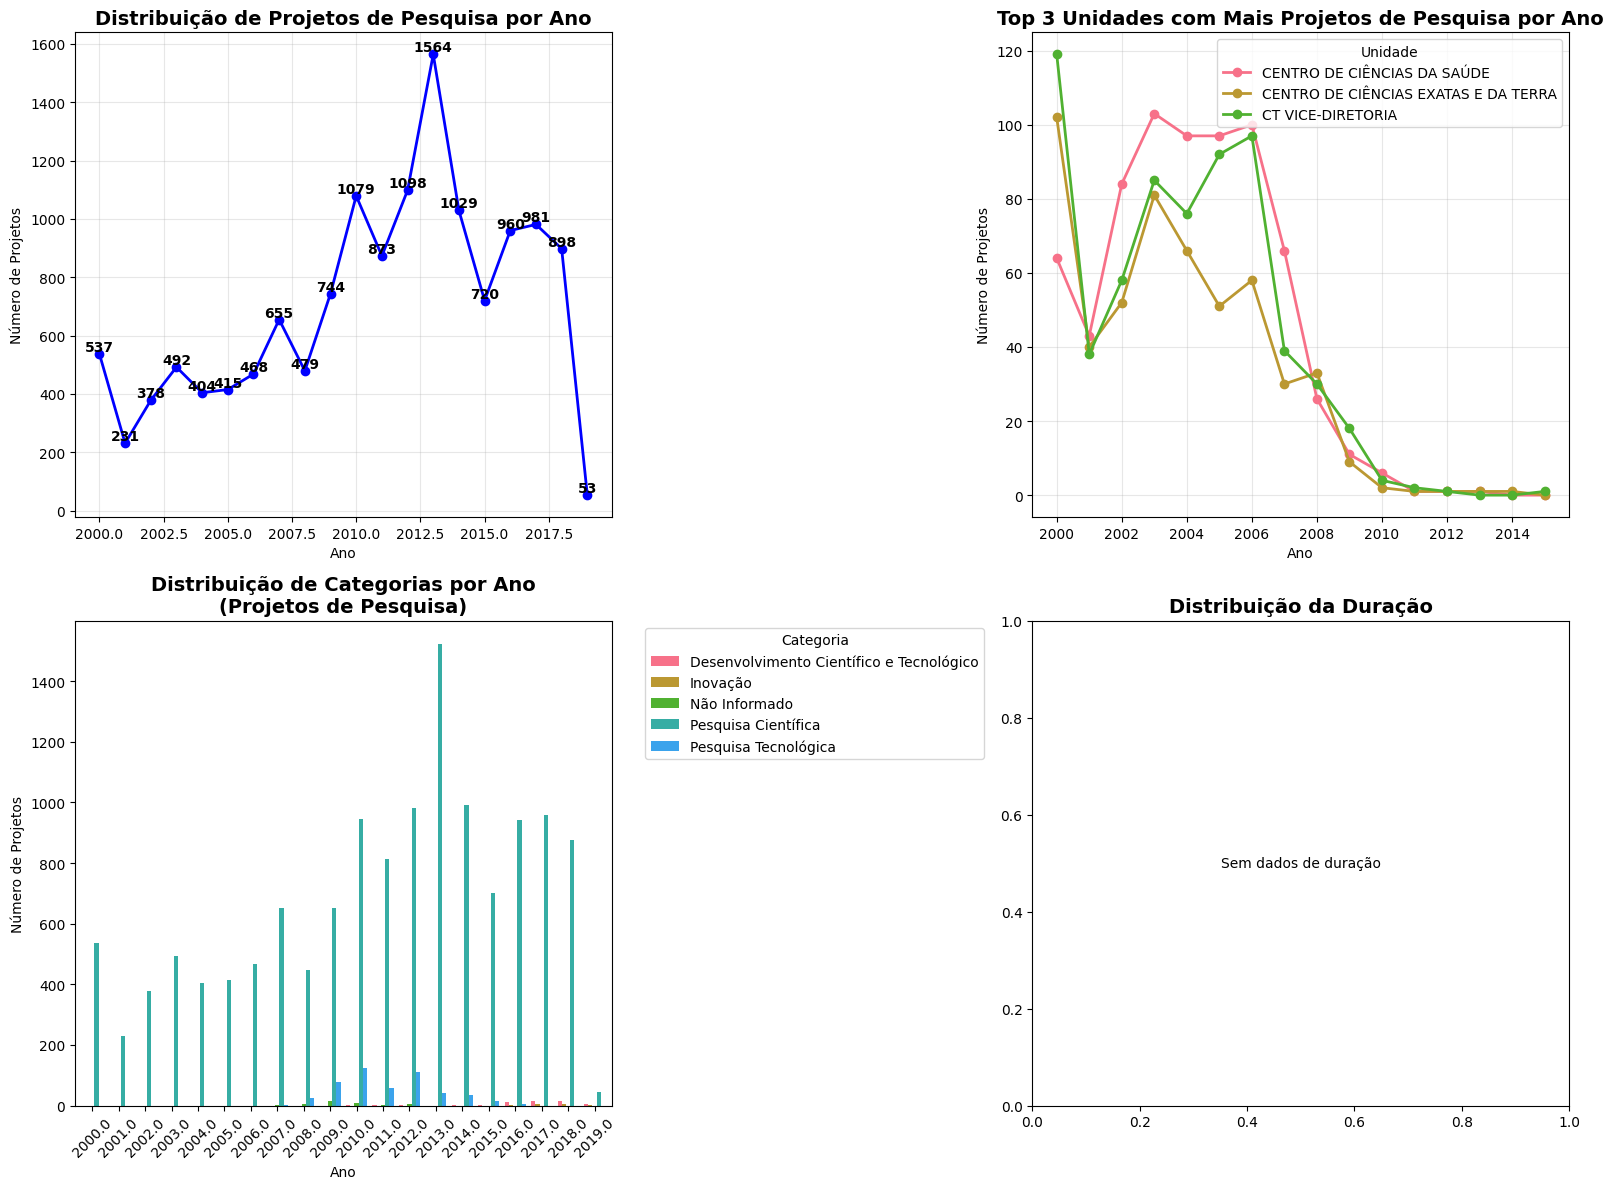

In [23]:
# 2. ANÁLISE PROJETOS DE PESQUISA

df_pesquisa = df[df['classificacao'] == 'pesquisa']
print(f"Total de projetos de pesquisa: {len(df_pesquisa)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 2.1 Distribuição de projetos por ano (Pesquisa)
if not df_pesquisa.empty:
    projetos_por_ano_pesquisa = df_pesquisa.groupby('ano').size()
    axes[0,0].plot(projetos_por_ano_pesquisa.index, projetos_por_ano_pesquisa.values, 
                   marker='o', linewidth=2, markersize=6, color='blue')
    axes[0,0].set_title('Distribuição de Projetos de Pesquisa por Ano', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Ano')
    axes[0,0].set_ylabel('Número de Projetos')
    axes[0,0].grid(True, alpha=0.3)
    
    # Adicionar valores nos pontos
    for ano, count in projetos_por_ano_pesquisa.items():
        axes[0,0].text(ano, count, f'{count}', ha='center', va='bottom', fontweight='bold')
else:
    axes[0,0].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[0,0].set_title('Distribuição de Projetos de Pesquisa por Ano', fontsize=14, fontweight='bold')

# 2.2 Top 3 unidades com mais projetos por ano (Pesquisa)
if not df_pesquisa.empty and 'unidade' in df_pesquisa.columns:
    top3_unidades_pesquisa = df_pesquisa['unidade'].value_counts().head(3).index
    top3_pesquisa_por_ano = df_pesquisa[df_pesquisa['unidade'].isin(top3_unidades_pesquisa)].groupby(['ano', 'unidade']).size().unstack(fill_value=0)
    
    if not top3_pesquisa_por_ano.empty:
        top3_pesquisa_por_ano.plot(kind='line', marker='o', ax=axes[0,1], linewidth=2, markersize=6)
        axes[0,1].set_title('Top 3 Unidades com Mais Projetos de Pesquisa por Ano', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Ano')
        axes[0,1].set_ylabel('Número de Projetos')
        axes[0,1].grid(True, alpha=0.3)
        axes[0,1].legend(title='Unidade')
    else:
        axes[0,1].text(0.5, 0.5, 'Sem dados suficientes', ha='center', va='center')
        axes[0,1].set_title('Top 3 Unidades - Projetos de Pesquisa', fontsize=14, fontweight='bold')
else:
    axes[0,1].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[0,1].set_title('Top 3 Unidades - Projetos de Pesquisa', fontsize=14, fontweight='bold')

# 2.3 Distribuição de categorias por ano (Pesquisa)
if not df_pesquisa.empty and 'categoria' in df_pesquisa.columns:
    # Pegar as categorias mais comuns
    categorias_comuns = df_pesquisa['categoria'].value_counts().head(5).index
    categoria_por_ano = df_pesquisa[df_pesquisa['categoria'].isin(categorias_comuns)].groupby(['ano', 'categoria']).size().unstack(fill_value=0)
    
    if not categoria_por_ano.empty:
        categoria_por_ano.plot(kind='bar', ax=axes[1,0], width=0.8)
        axes[1,0].set_title('Distribuição de Categorias por Ano\n(Projetos de Pesquisa)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Ano')
        axes[1,0].set_ylabel('Número de Projetos')
        axes[1,0].legend(title='Categoria', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1,0].tick_params(axis='x', rotation=45)
    else:
        axes[1,0].text(0.5, 0.5, 'Sem dados de categorias', ha='center', va='center')
        axes[1,0].set_title('Distribuição de Categorias por Ano', fontsize=14, fontweight='bold')
else:
    axes[1,0].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[1,0].set_title('Distribuição de Categorias por Ano', fontsize=14, fontweight='bold')

# 2.4 Distribuição da duração (Pesquisa)
if not df_pesquisa.empty and 'duracao' in df_pesquisa.columns:
    duracao_pesquisa = df_pesquisa['duracao'].dropna()
    if not duracao_pesquisa.empty:
        axes[1,1].hist(duracao_pesquisa, bins=20, alpha=0.7, color='green', edgecolor='black')
        axes[1,1].set_title('Distribuição da Duração\n(Projetos de Pesquisa)', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Duração (dias)')
        axes[1,1].set_ylabel('Número de Projetos')
        
        # Adicionar estatísticas
        media_duracao = duracao_pesquisa.mean()
        mediana_duracao = duracao_pesquisa.median()
        axes[1,1].axvline(media_duracao, color='red', linestyle='--', label=f'Média: {media_duracao:.1f} dias')
        axes[1,1].axvline(mediana_duracao, color='blue', linestyle='--', label=f'Mediana: {mediana_duracao:.1f} dias')
        axes[1,1].legend()
    else:
        axes[1,1].text(0.5, 0.5, 'Sem dados de duração', ha='center', va='center')
        axes[1,1].set_title('Distribuição da Duração', fontsize=14, fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[1,1].set_title('Distribuição da Duração', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Total de TCCs: 77906


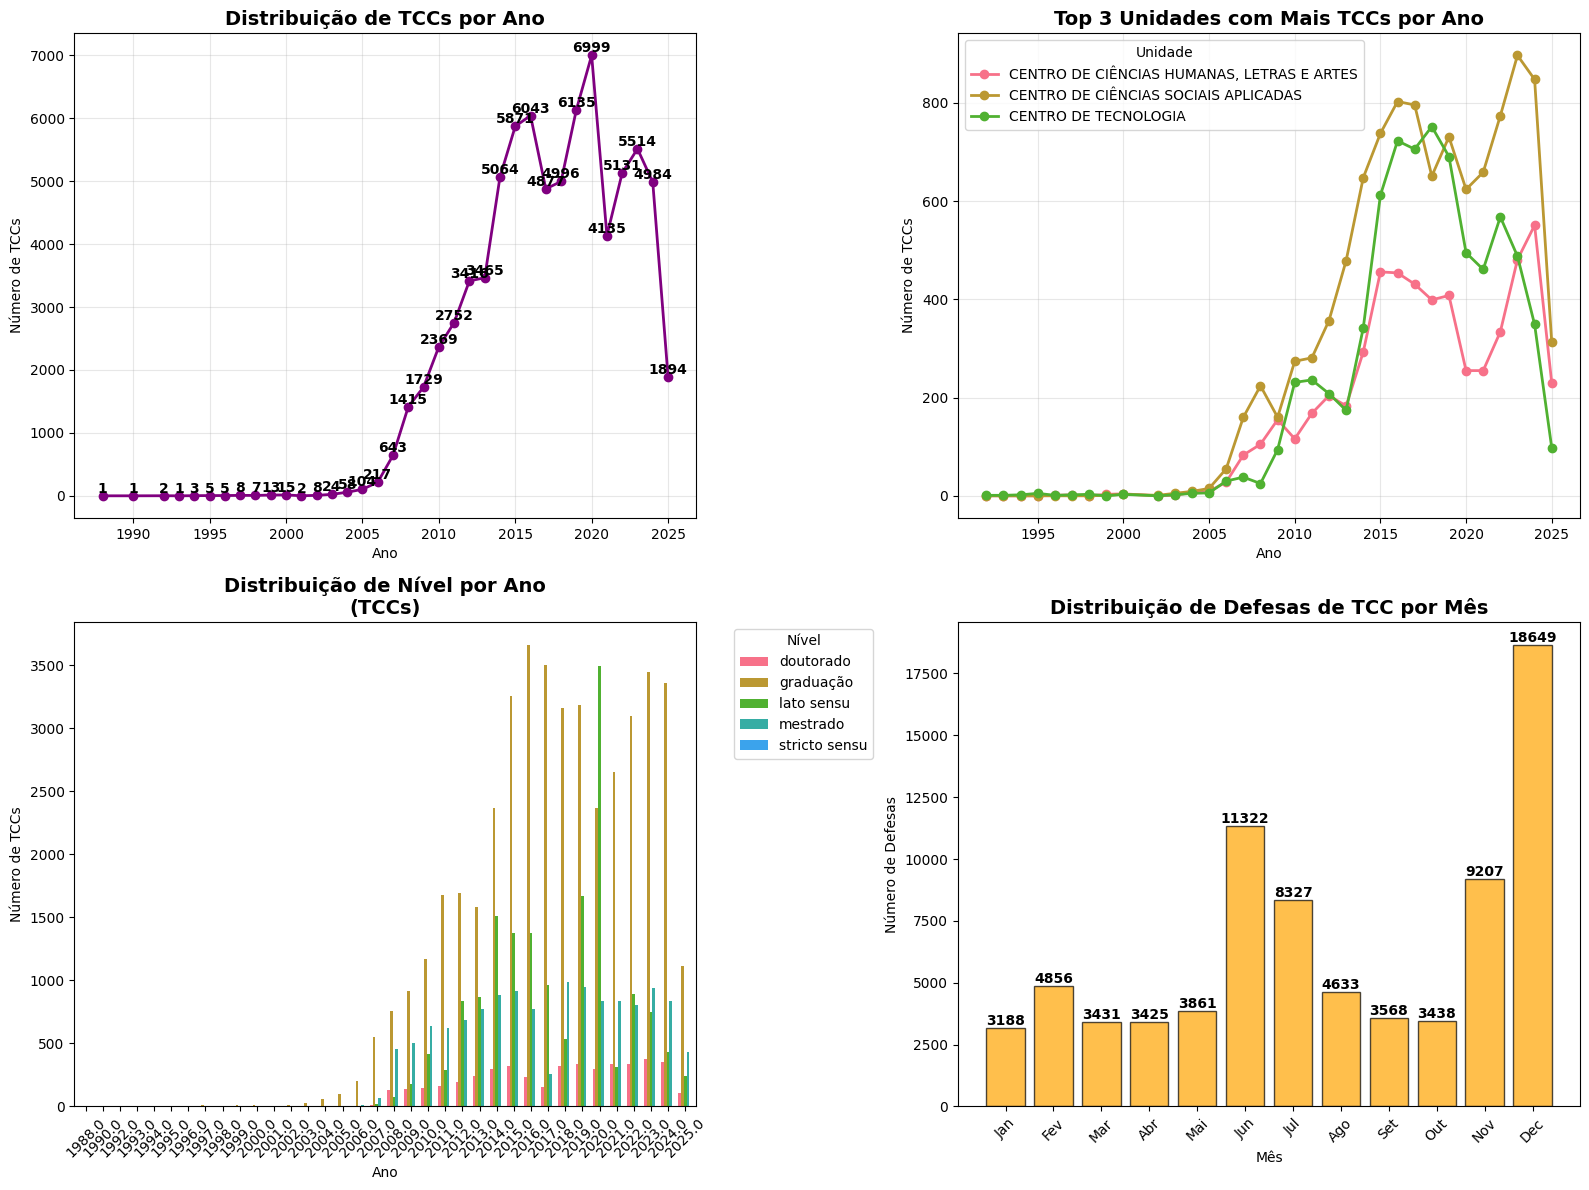

In [24]:
# 3. ANÁLISE APENAS TCCs

df_tcc = df[df['classificacao'] == 'tcc']
print(f"Total de TCCs: {len(df_tcc)}")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 3.1 Distribuição de TCCs por ano
if not df_tcc.empty:
    tcc_por_ano = df_tcc.groupby('ano').size()
    axes[0,0].plot(tcc_por_ano.index, tcc_por_ano.values, 
                   marker='o', linewidth=2, markersize=6, color='purple')
    axes[0,0].set_title('Distribuição de TCCs por Ano', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Ano')
    axes[0,0].set_ylabel('Número de TCCs')
    axes[0,0].grid(True, alpha=0.3)
    
    # Adicionar valores nos pontos
    for ano, count in tcc_por_ano.items():
        axes[0,0].text(ano, count, f'{count}', ha='center', va='bottom', fontweight='bold')
else:
    axes[0,0].text(0.5, 0.5, 'Sem TCCs', ha='center', va='center')
    axes[0,0].set_title('Distribuição de TCCs por Ano', fontsize=14, fontweight='bold')

# 3.2 Top 3 unidades com mais TCCs por ano
if not df_tcc.empty and 'unidade' in df_tcc.columns:
    top3_unidades_tcc = df_tcc['unidade'].value_counts().head(3).index
    top3_tcc_por_ano = df_tcc[df_tcc['unidade'].isin(top3_unidades_tcc)].groupby(['ano', 'unidade']).size().unstack(fill_value=0)
    
    if not top3_tcc_por_ano.empty:
        top3_tcc_por_ano.plot(kind='line', marker='o', ax=axes[0,1], linewidth=2, markersize=6)
        axes[0,1].set_title('Top 3 Unidades com Mais TCCs por Ano', fontsize=14, fontweight='bold')
        axes[0,1].set_xlabel('Ano')
        axes[0,1].set_ylabel('Número de TCCs')
        axes[0,1].grid(True, alpha=0.3)
        axes[0,1].legend(title='Unidade')
    else:
        axes[0,1].text(0.5, 0.5, 'Sem dados suficientes', ha='center', va='center')
        axes[0,1].set_title('Top 3 Unidades - TCCs', fontsize=14, fontweight='bold')
else:
    axes[0,1].text(0.5, 0.5, 'Sem TCCs', ha='center', va='center')
    axes[0,1].set_title('Top 3 Unidades - TCCs', fontsize=14, fontweight='bold')

# 3.3 Distribuição de nível por ano (TCCs)
if not df_tcc.empty and 'nivel' in df_tcc.columns:
    nivel_por_ano = pd.crosstab(df_tcc['ano'], df_tcc['nivel'])
    if not nivel_por_ano.empty:
        nivel_por_ano.plot(kind='bar', ax=axes[1,0], width=0.8)
        axes[1,0].set_title('Distribuição de Nível por Ano\n(TCCs)', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Ano')
        axes[1,0].set_ylabel('Número de TCCs')
        axes[1,0].legend(title='Nível', bbox_to_anchor=(1.05, 1), loc='upper left')
        axes[1,0].tick_params(axis='x', rotation=45)
    else:
        axes[1,0].text(0.5, 0.5, 'Sem dados de nível', ha='center', va='center')
        axes[1,0].set_title('Distribuição de Nível por Ano', fontsize=14, fontweight='bold')
else:
    axes[1,0].text(0.5, 0.5, 'Sem TCCs', ha='center', va='center')
    axes[1,0].set_title('Distribuição de Nível por Ano', fontsize=14, fontweight='bold')

# 3.4 Distribuição data de defesa (data_fim) - TCCs
if not df_tcc.empty and 'data_fim' in df_tcc.columns:
    # Extrair mês e ano da data de defesa
    df_tcc_copy = df_tcc.copy()
    df_tcc_copy['mes_defesa'] = df_tcc_copy['data_fim'].dt.month
    df_tcc_copy['ano_defesa'] = df_tcc_copy['data_fim'].dt.year
    
    # Contar defesas por mês (agregando todos os anos)
    defesas_por_mes = df_tcc_copy['mes_defesa'].value_counts().sort_index()
    
    if not defesas_por_mes.empty:
        meses = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 
                'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dec']
        meses_labels = [meses[int(i)-1] if int(i) <= len(meses) else f'Mês {int(i)}' 
                for i in defesas_por_mes.index]
        
        bars = axes[1,1].bar(range(len(defesas_por_mes)), defesas_por_mes.values, 
                           color='orange', alpha=0.7, edgecolor='black')
        axes[1,1].set_title('Distribuição de Defesas de TCC por Mês', fontsize=14, fontweight='bold')
        axes[1,1].set_xlabel('Mês')
        axes[1,1].set_ylabel('Número de Defesas')
        axes[1,1].set_xticks(range(len(defesas_por_mes)))
        axes[1,1].set_xticklabels(meses_labels, rotation=45)
        
        # Adicionar valores nas barras
        for bar in bars:
            height = bar.get_height()
            axes[1,1].text(bar.get_x() + bar.get_width()/2., height,
                          f'{int(height)}', ha='center', va='bottom', fontweight='bold')
    else:
        axes[1,1].text(0.5, 0.5, 'Sem datas de defesa', ha='center', va='center')
        axes[1,1].set_title('Distribuição de Defesas por Mês', fontsize=14, fontweight='bold')
else:
    axes[1,1].text(0.5, 0.5, 'Sem TCCs ou datas de defesa', ha='center', va='center')
    axes[1,1].set_title('Distribuição de Defesas por Mês', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

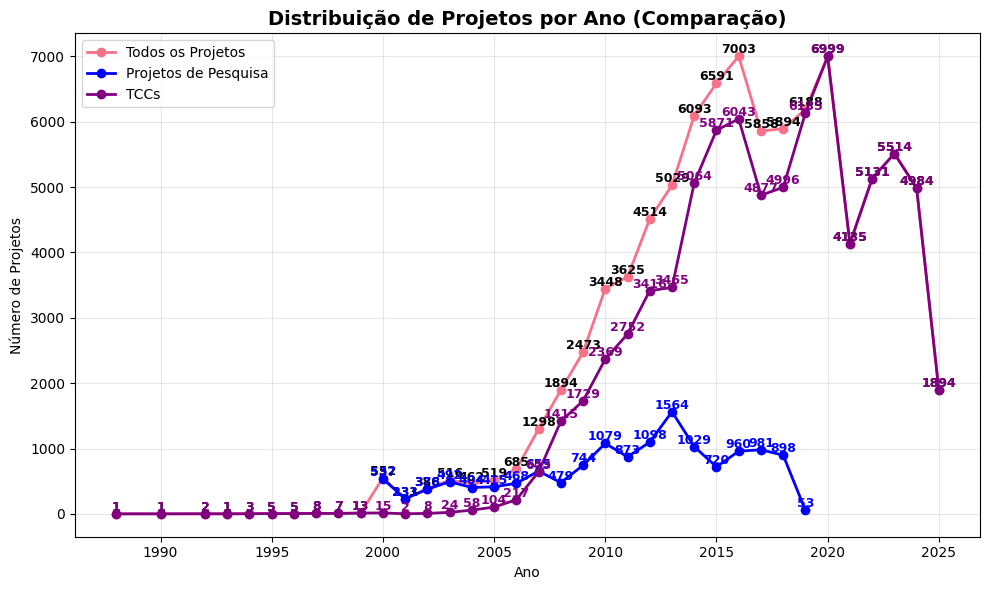

In [25]:
# 4. COMPARAÇÃO SOBREPOSTA

fig, ax = plt.subplots(figsize=(10, 6))

# 4.1 Distribuição de projetos por ano (Geral)
projetos_por_ano_geral = df.groupby('ano').size()
ax.plot(projetos_por_ano_geral.index, projetos_por_ano_geral.values, 
        marker='o', linewidth=2, markersize=6, label='Todos os Projetos')

# 4.2 Distribuição de projetos por ano (Pesquisa)
if not df_pesquisa.empty:
    projetos_por_ano_pesquisa = df_pesquisa.groupby('ano').size()
    ax.plot(projetos_por_ano_pesquisa.index, projetos_por_ano_pesquisa.values, 
            marker='o', linewidth=2, markersize=6, color='blue', label='Projetos de Pesquisa')

# 4.3 Distribuição de TCCs por ano
if not df_tcc.empty:
    tcc_por_ano = df_tcc.groupby('ano').size()
    ax.plot(tcc_por_ano.index, tcc_por_ano.values, 
            marker='o', linewidth=2, markersize=6, color='purple', label='TCCs')

# Personalização geral
ax.set_title('Distribuição de Projetos por Ano (Comparação)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ano')
ax.set_ylabel('Número de Projetos')
ax.grid(True, alpha=0.3)
ax.legend()

# Adicionar valores nos pontos
def adicionar_valores(series, cor='black'):
    for ano, count in series.items():
        ax.text(ano, count + 0.1, f'{count}', ha='center', va='bottom', fontsize=9, color=cor, fontweight='bold')

adicionar_valores(projetos_por_ano_geral)
if not df_pesquisa.empty:
    adicionar_valores(projetos_por_ano_pesquisa, cor='blue')
if not df_tcc.empty:
    adicionar_valores(tcc_por_ano, cor='purple')

plt.tight_layout()
plt.show()


In [26]:
# TCC X PESQUISA
print("\n" + "=" * 50)
print("DISTRIBUIÇÃO DE TCC E PESQUISA NO DATASET")
print("=" * 50)
print(f"Total de projetos no dataset: {len(df)}")
print(f"Projetos de pesquisa: {len(df_pesquisa)} ({len(df_pesquisa)/len(df)*100:.1f}%)")
print(f"TCCs: {len(df_tcc)} ({len(df_tcc)/len(df)*100:.1f}%)")


DISTRIBUIÇÃO DE TCC E PESQUISA NO DATASET
Total de projetos no dataset: 91964
Projetos de pesquisa: 14058 (15.3%)
TCCs: 77906 (84.7%)


In [27]:
# Garante que não há valores ausentes nas colunas de interesse
df['categoria'] = df['categoria'].fillna('Não especificada')
df['unidade'] = df['unidade'].fillna('Não especificada')

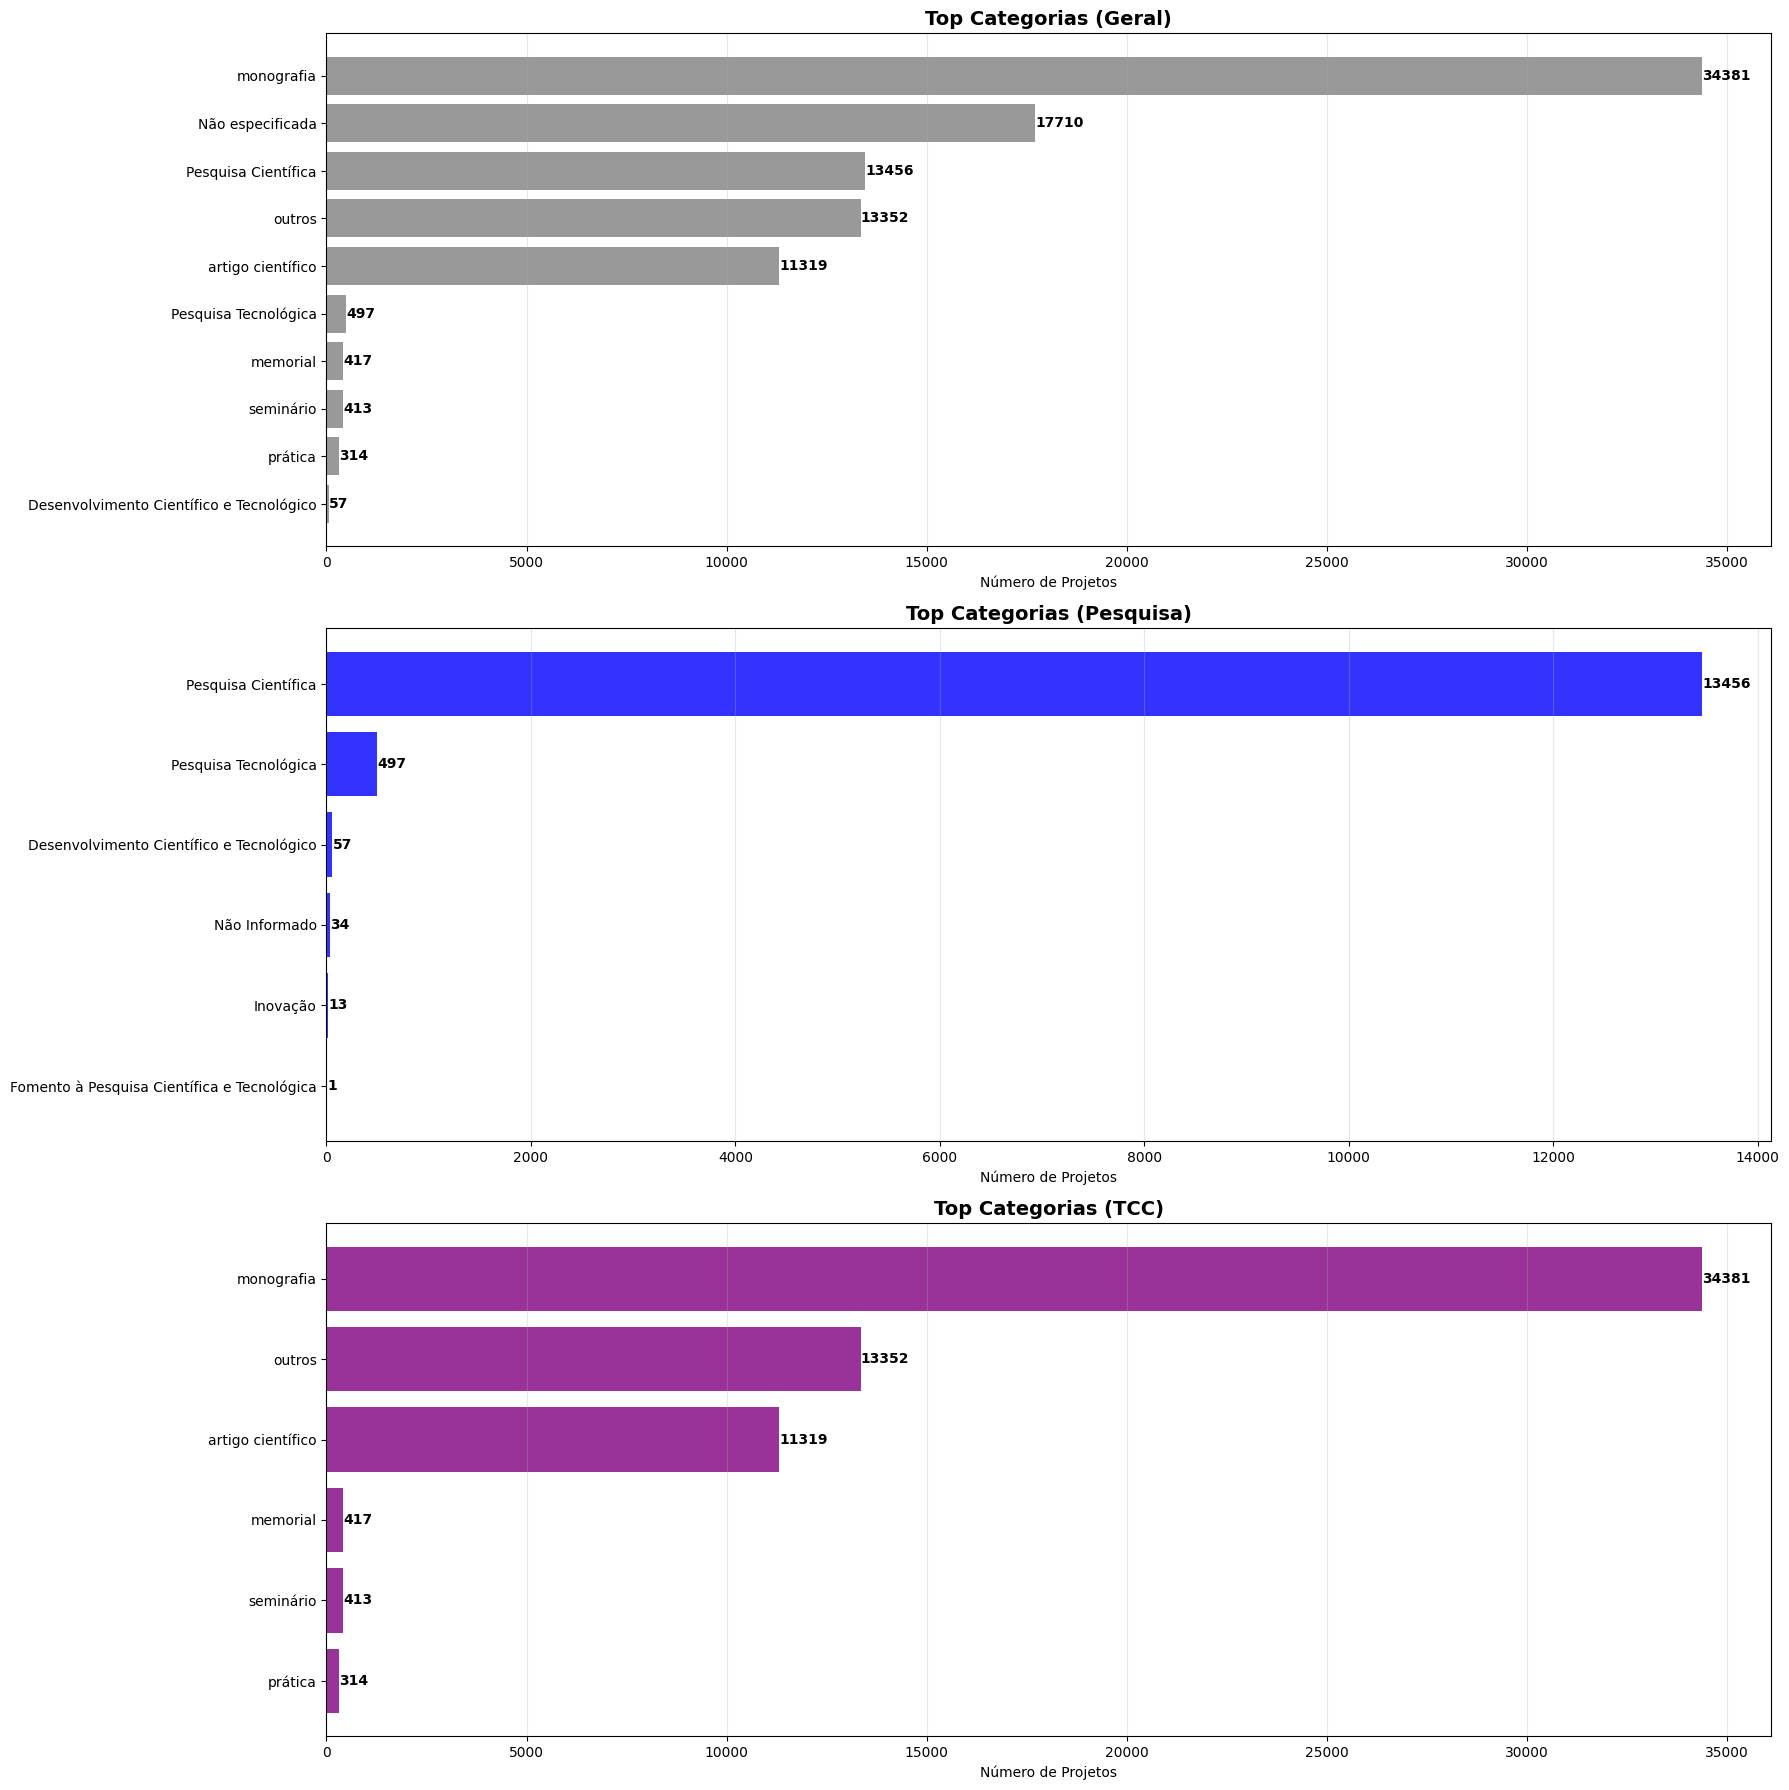

In [28]:
# TOP CATEGORIAS 

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# 1.1 Geral
top_categorias_geral = df['categoria'].value_counts().head(10)
axes[0].barh(top_categorias_geral.index[::-1], top_categorias_geral.values[::-1], color='gray', alpha=0.8)
axes[0].set_title('Top Categorias (Geral)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Projetos')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_categorias_geral.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# 1.2 Pesquisa
if not df_pesquisa.empty:
    top_categorias_pesquisa = df_pesquisa['categoria'].value_counts().head(10)
    axes[1].barh(top_categorias_pesquisa.index[::-1], top_categorias_pesquisa.values[::-1], color='blue', alpha=0.8)
    axes[1].set_title('Top Categorias (Pesquisa)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Número de Projetos')
    axes[1].grid(axis='x', alpha=0.3)
    for i, v in enumerate(top_categorias_pesquisa.values[::-1]):
        axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[1].set_title('Top Categorias (Pesquisa)', fontsize=14, fontweight='bold')

# 1.3 TCC
if not df_tcc.empty:
    top_categorias_tcc = df_tcc['categoria'].value_counts().head(10)
    axes[2].barh(top_categorias_tcc.index[::-1], top_categorias_tcc.values[::-1], color='purple', alpha=0.8)
    axes[2].set_title('Top Categorias (TCC)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Número de Projetos')
    axes[2].grid(axis='x', alpha=0.3)
    for i, v in enumerate(top_categorias_tcc.values[::-1]):
        axes[2].text(v + 5, i, str(v), va='center', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Sem TCCs', ha='center', va='center')
    axes[2].set_title('Top Categorias (TCC)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

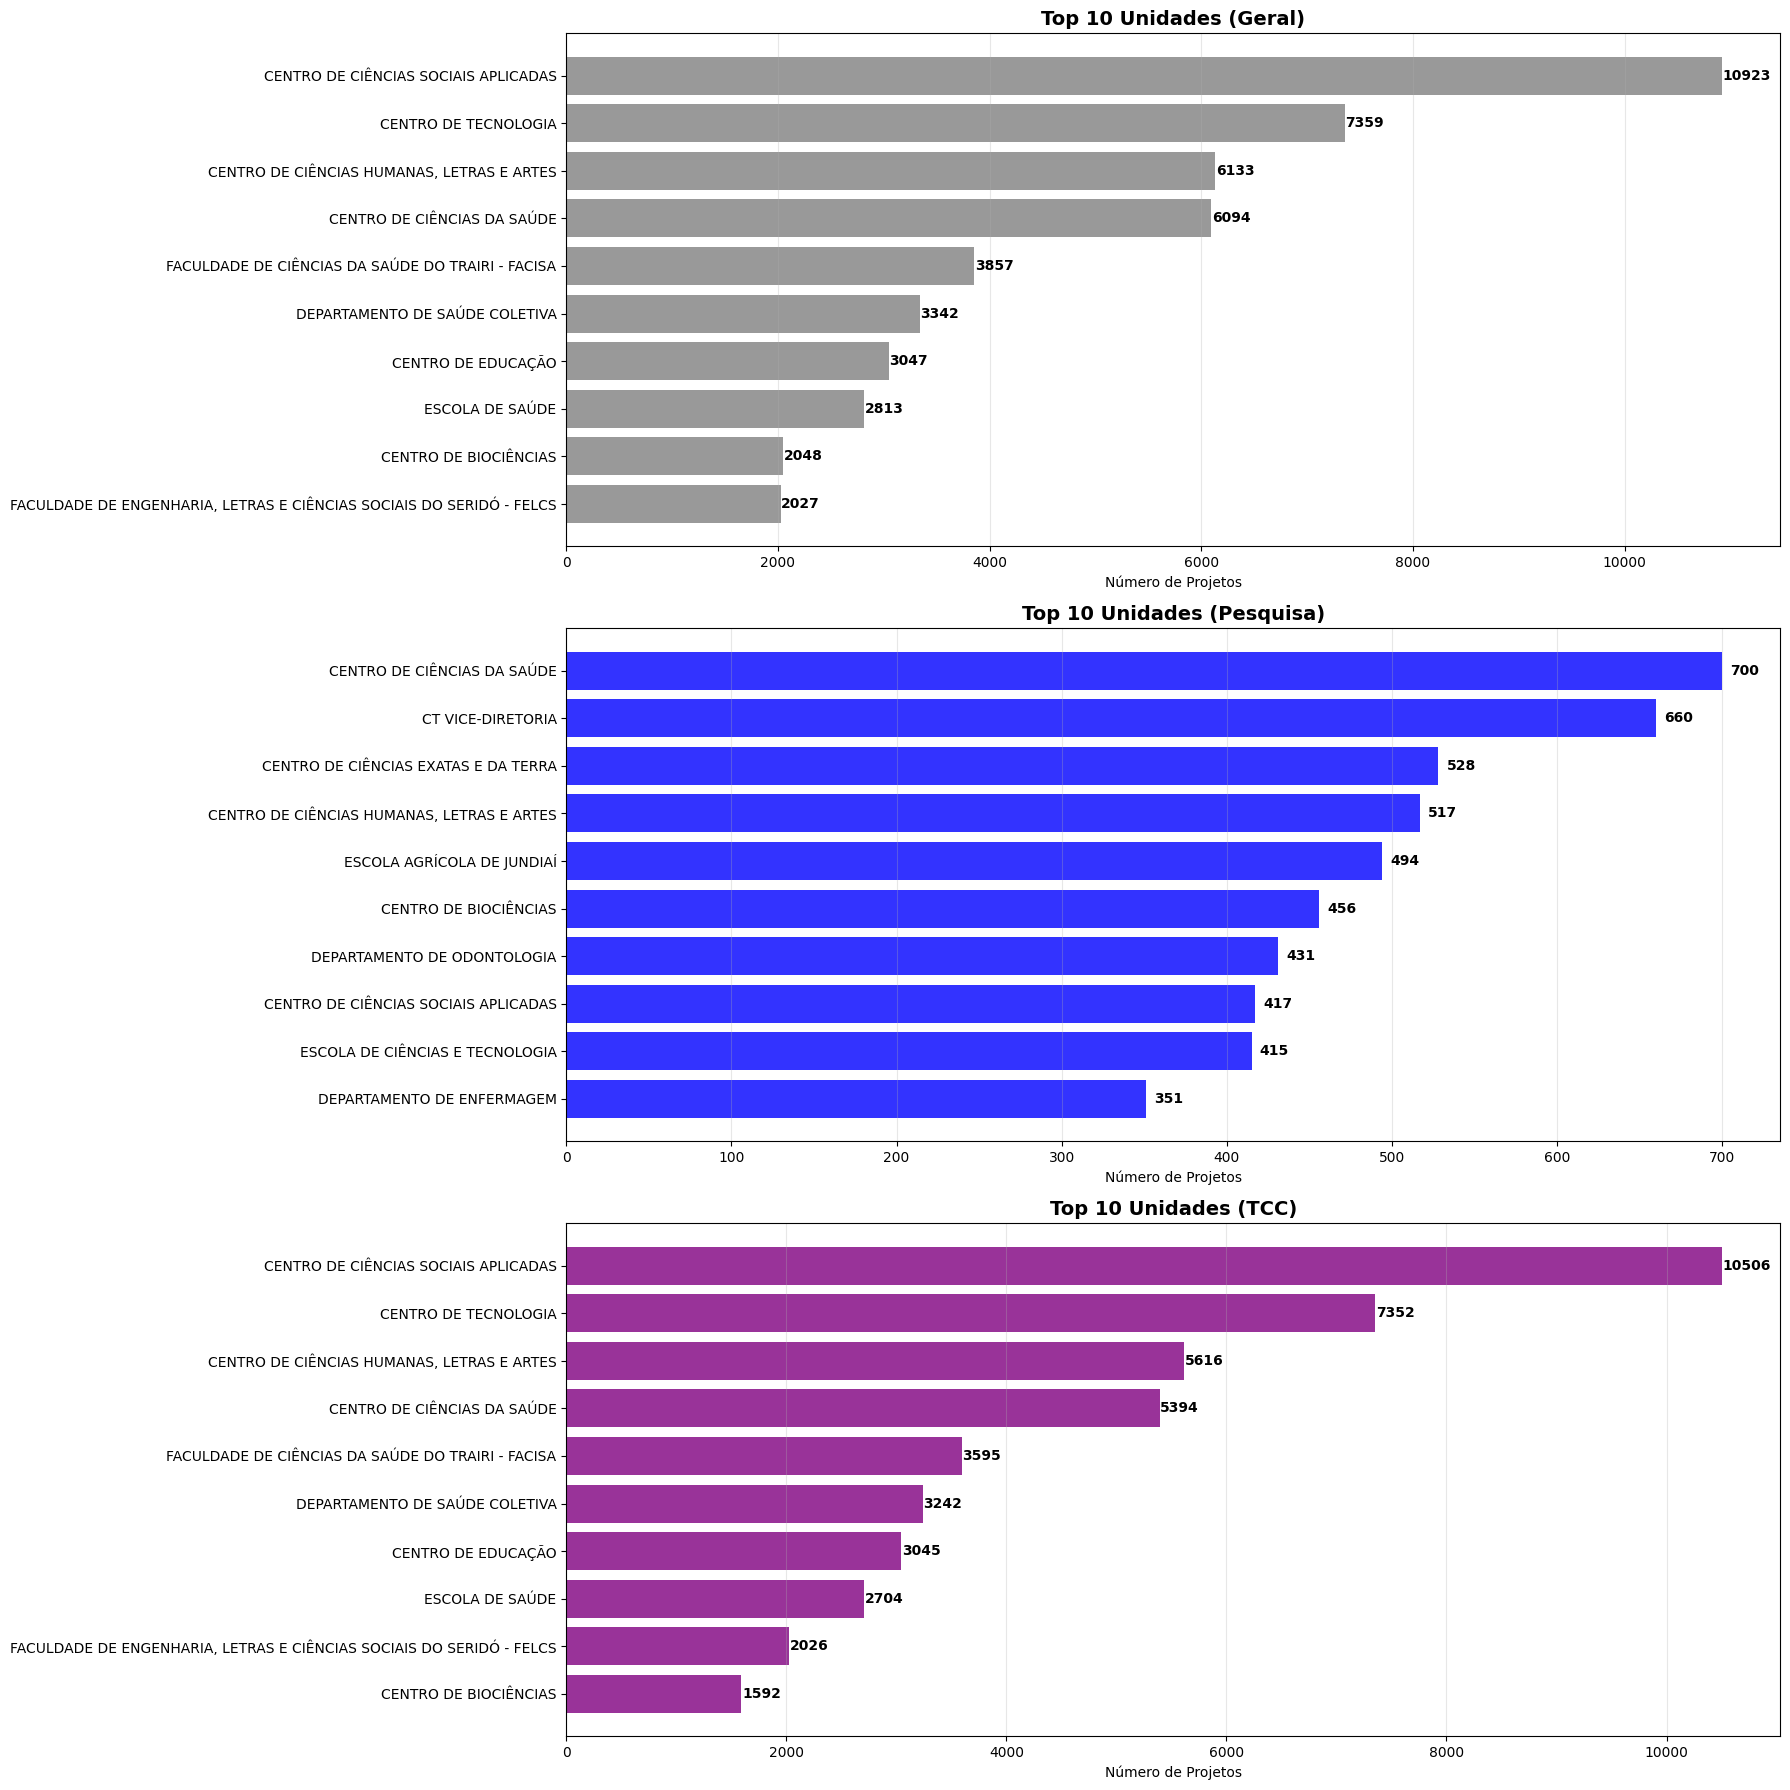

In [29]:
# TOP 10 UNIDADES

fig, axes = plt.subplots(3, 1, figsize=(18, 18))

# 2.1 Geral
top_unidades_geral = df['unidade'].value_counts().head(10)
axes[0].barh(top_unidades_geral.index[::-1], top_unidades_geral.values[::-1], color='gray', alpha=0.8)
axes[0].set_title('Top 10 Unidades (Geral)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Número de Projetos')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_unidades_geral.values[::-1]):
    axes[0].text(v + 5, i, str(v), va='center', fontweight='bold')

# 2.2 Pesquisa
if not df_pesquisa.empty:
    top_unidades_pesquisa = df_pesquisa['unidade'].value_counts().head(10)
    axes[1].barh(top_unidades_pesquisa.index[::-1], top_unidades_pesquisa.values[::-1], color='blue', alpha=0.8)
    axes[1].set_title('Top 10 Unidades (Pesquisa)', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Número de Projetos')
    axes[1].grid(axis='x', alpha=0.3)
    for i, v in enumerate(top_unidades_pesquisa.values[::-1]):
        axes[1].text(v + 5, i, str(v), va='center', fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Sem projetos de pesquisa', ha='center', va='center')
    axes[1].set_title('Top 10 Unidades (Pesquisa)', fontsize=14, fontweight='bold')

# 2.3 TCC
if not df_tcc.empty:
    top_unidades_tcc = df_tcc['unidade'].value_counts().head(10)
    axes[2].barh(top_unidades_tcc.index[::-1], top_unidades_tcc.values[::-1], color='purple', alpha=0.8)
    axes[2].set_title('Top 10 Unidades (TCC)', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Número de Projetos')
    axes[2].grid(axis='x', alpha=0.3)
    for i, v in enumerate(top_unidades_tcc.values[::-1]):
        axes[2].text(v + 5, i, str(v), va='center', fontweight='bold')
else:
    axes[2].text(0.5, 0.5, 'Sem TCCs', ha='center', va='center')
    axes[2].set_title('Top 10 Unidades (TCC)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [30]:
df_tokens = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

/tmp/ipykernel_56912/1118112468.py:1: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tokens = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


/tmp/ipykernel_56912/1417044466.py:6: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens (>= 2000): ['saude', 'educacao', 'ensino', 'gestao', 'estado']


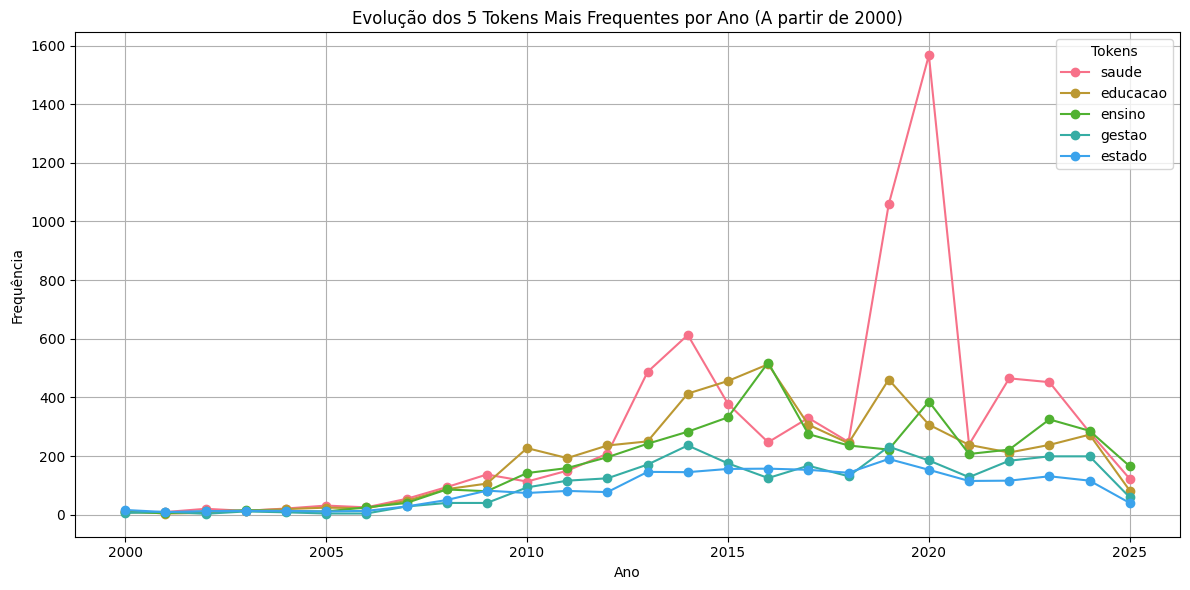

In [46]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for years >= 2000
df_filtered = df[df['ano'] >= 2000].copy()

# Convert 'tokens' from string to list
df_filtered['tokens'] = df_filtered['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered.explode('tokens')

# Calculate the top 5 tokens for this filtered period
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens (>= 2000): {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title('Evolução dos 5 Tokens Mais Frequentes por Ano (A partir de 2000)')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_2000_line_chart.png')

/tmp/ipykernel_56912/649624064.py:6: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE CIÊNCIAS SOCIAIS APLICADAS: ['direito', 'lei', 'saude', 'luz', 'direitos']


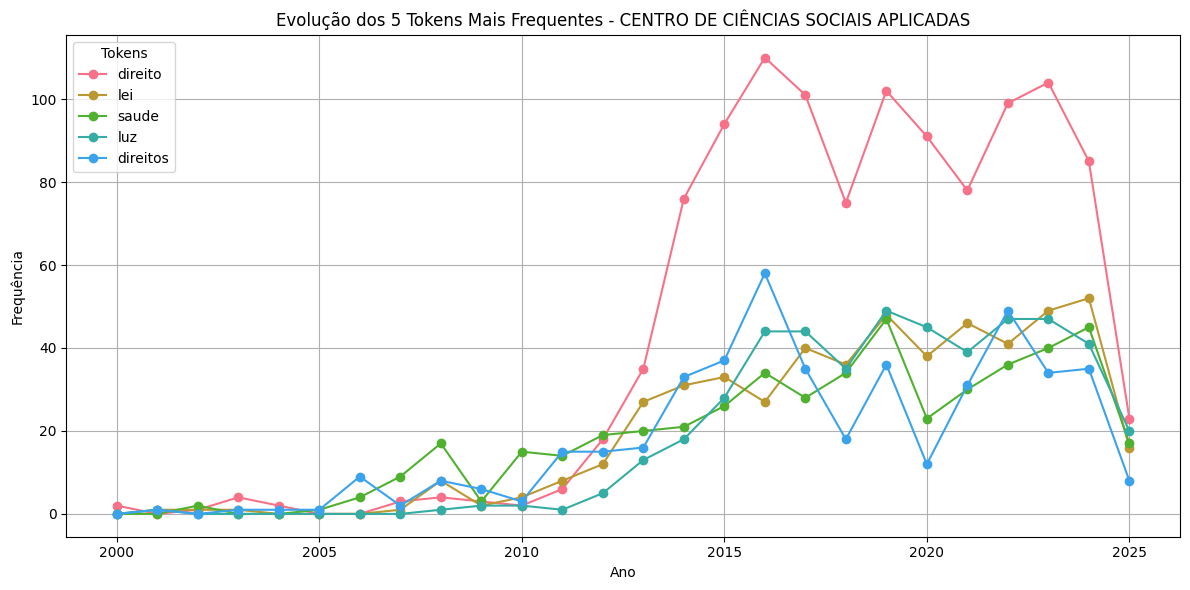

In [32]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit
target_unit = 'CENTRO DE CIÊNCIAS SOCIAIS APLICADAS'
df_filtered_unit = df[df['unidade'] == target_unit].copy()

# Convert 'tokens' from string to list
df_filtered_unit['tokens'] = df_filtered_unit['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered_unit.explode('tokens')

# Calculate the top 5 tokens for this unit
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit}: {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes - {target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_ccsa_line_chart.png')

/tmp/ipykernel_56912/3215929129.py:2: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE TECNOLOGIA: ['utilizando', 'controle', 'agua', 'energia', 'sistemas']


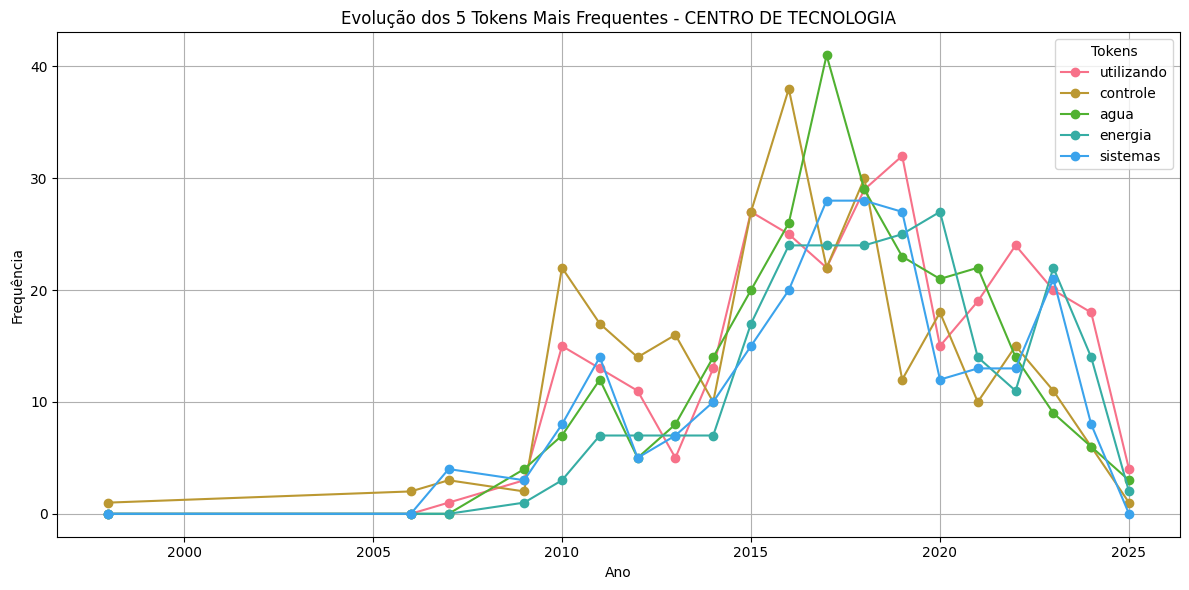

In [33]:
# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit
target_unit = 'CENTRO DE TECNOLOGIA'
df_filtered_unit = df[df['unidade'] == target_unit].copy()

# Convert 'tokens' from string to list
df_filtered_unit['tokens'] = df_filtered_unit['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered_unit.explode('tokens')

# Calculate the top 5 tokens for this unit
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit}: {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes - {target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_ccsa_line_chart.png')

/tmp/ipykernel_56912/1709942247.py:6: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES: ['ensino', 'historia', 'cidade', 'comunicacao', 'design']


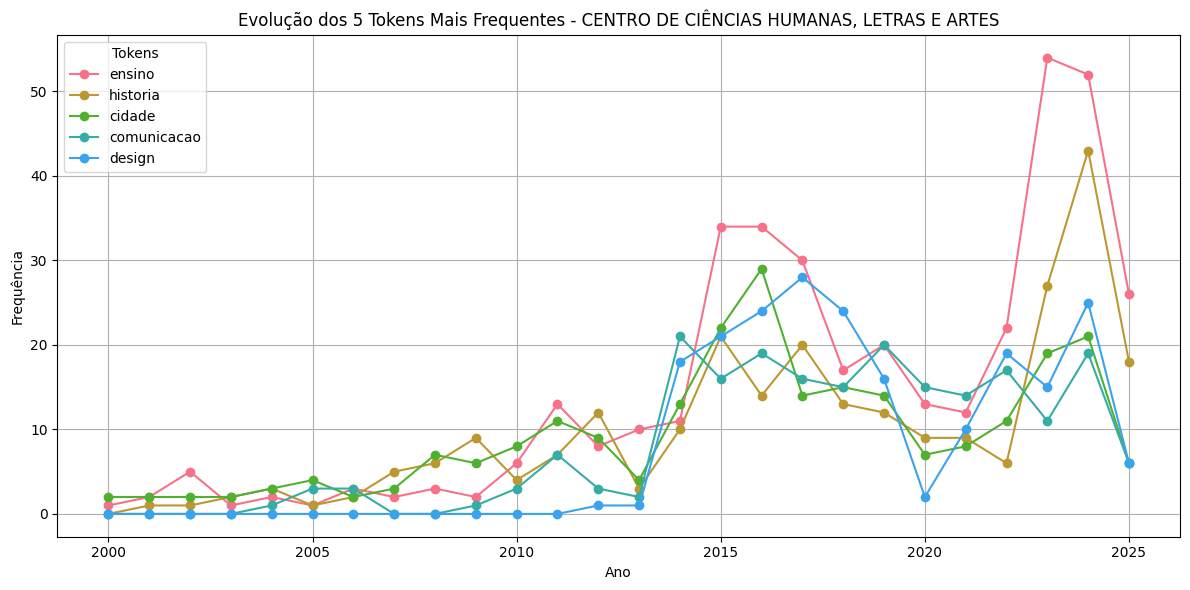

In [34]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit
target_unit = 'CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES'
df_filtered_unit = df[df['unidade'] == target_unit].copy()

# Convert 'tokens' from string to list
df_filtered_unit['tokens'] = df_filtered_unit['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered_unit.explode('tokens')

# Calculate the top 5 tokens for this unit
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit}: {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes - {target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_ccsa_line_chart.png')

/tmp/ipykernel_56912/478051390.py:2: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE CIÊNCIAS DA SAÚDE: ['fisica', 'educacao', 'pacientes', 'saude', 'ensino']


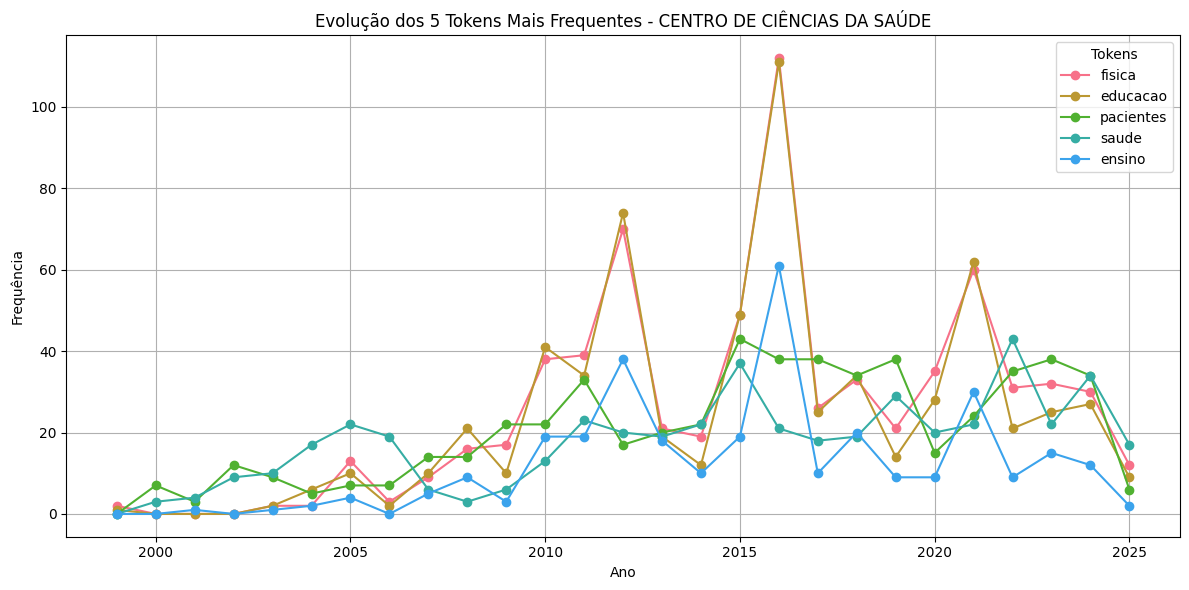

In [35]:
# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit
target_unit = 'CENTRO DE CIÊNCIAS DA SAÚDE'
df_filtered_unit = df[df['unidade'] == target_unit].copy()

# Convert 'tokens' from string to list
df_filtered_unit['tokens'] = df_filtered_unit['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered_unit.explode('tokens')

# Calculate the top 5 tokens for this unit
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit}: {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes - {target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_ccsa_line_chart.png')

/tmp/ipykernel_56912/52041943.py:2: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE EDUCAÇÃO: ['educacao', 'ensino', 'infantil', 'escola', 'formacao']


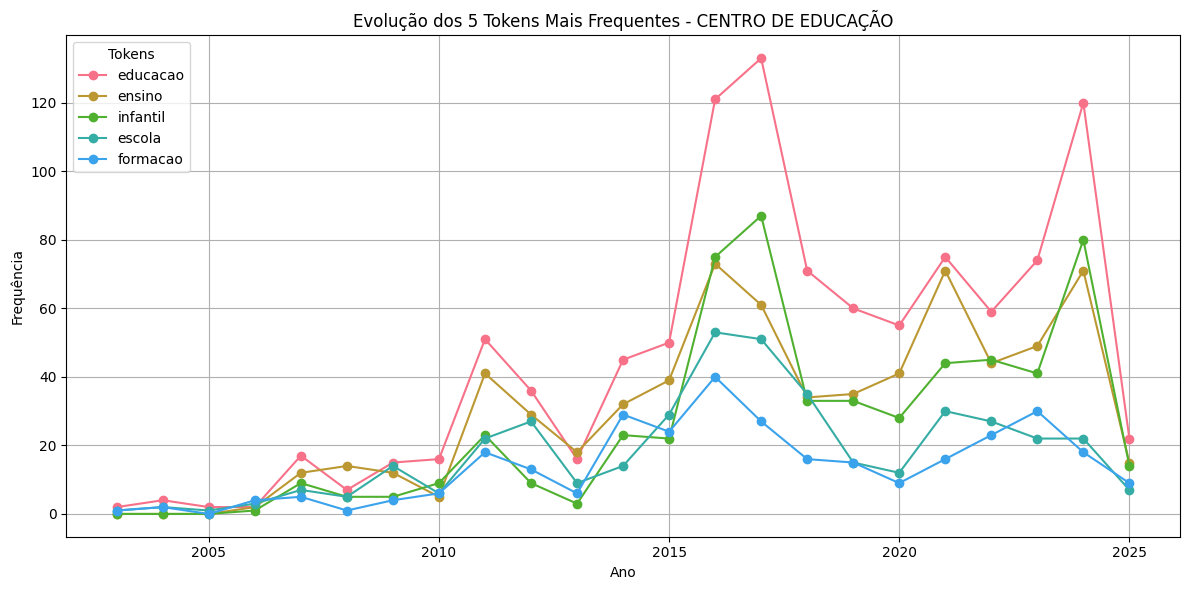

In [43]:


# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit
target_unit = 'CENTRO DE EDUCAÇÃO'
df_filtered_unit = df[(df['unidade'] == target_unit) & (df['ano'] >= 2000)].copy()

# Convert 'tokens' from string to list
df_filtered_unit['tokens'] = df_filtered_unit['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered_unit.explode('tokens')

# Calculate the top 5 tokens for this unit
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit}: {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes - {target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_ccsa_line_chart.png')

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91964 entries, 0 to 91963
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   titulo                  91964 non-null  object 
 1   nome_orientador         77906 non-null  object 
 2   nivel                   91964 non-null  object 
 3   ano                     91964 non-null  float64
 4   classificacao           91964 non-null  object 
 5   unidade                 91624 non-null  object 
 6   palavras_chave          13836 non-null  object 
 7   data_inicio             91961 non-null  object 
 8   data_fim                91733 non-null  object 
 9   situacao                91964 non-null  object 
 10  tipo_projeto            91964 non-null  object 
 11  linha_pesquisa          13611 non-null  object 
 12  area_conhecimento_cnpq  13744 non-null  object 
 13  categoria               74254 non-null  object 
 14  titulo2                 91952 non-null

In [38]:
df_filtrado = df[df['classificacao']=='pesquisa']

In [39]:
df_filtrado['tipo_projeto'].value_counts()

tipo_projeto
INTERNO    10644
EXTERNO     3414
Name: count, dtype: int64

/tmp/ipykernel_56912/2178475371.py:1: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


['INTERNO' 'EXTERNO']


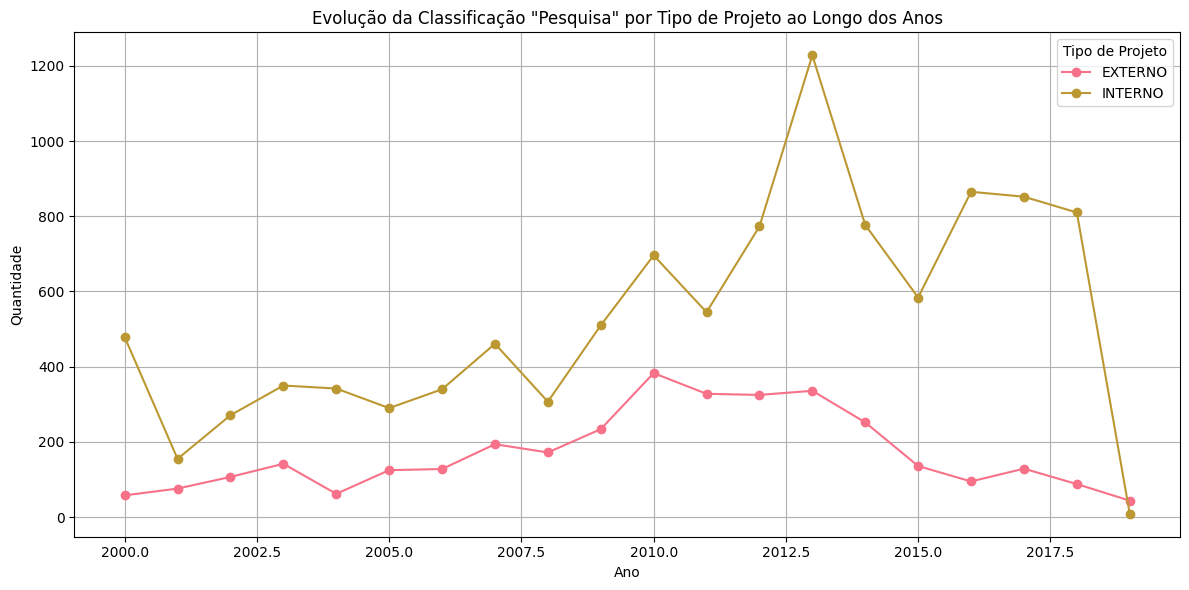

In [40]:
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for 'pesquisa' classification
df_pesquisa = df[df['classificacao'] == 'pesquisa']

# Check unique values of 'tipo_projeto'
print(df_pesquisa['tipo_projeto'].unique())

# Group by year and project type
df_grouped = df_pesquisa.groupby(['ano', 'tipo_projeto']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for column in df_grouped.columns:
    plt.plot(df_grouped.index, df_grouped[column], label=column, marker='o')

plt.title('Evolução da Classificação "Pesquisa" por Tipo de Projeto ao Longo dos Anos')
plt.xlabel('Ano')
plt.ylabel('Quantidade')
plt.legend(title='Tipo de Projeto')
plt.grid(True)
plt.tight_layout()
plt.savefig('pesquisa_tipo_projeto_line_chart.png')

/tmp/ipykernel_56912/1659382653.py:5: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


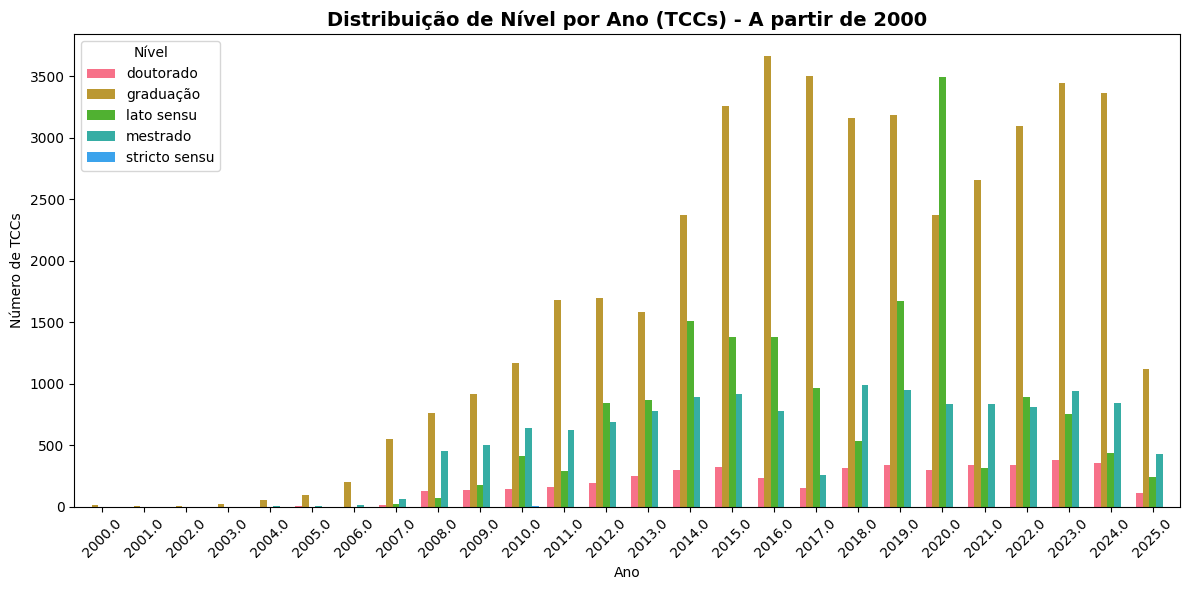

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for TCC and Year >= 2000
df_tcc_filtered = df[(df['classificacao'] == 'tcc') & (df['ano'] >= 2000)]

# Check if data exists after filtering
if not df_tcc_filtered.empty and 'nivel' in df_tcc_filtered.columns:
    nivel_por_ano = pd.crosstab(df_tcc_filtered['ano'], df_tcc_filtered['nivel'])
    
    if not nivel_por_ano.empty:
        plt.figure(figsize=(12, 6))
        nivel_por_ano.plot(kind='bar', width=0.8, ax=plt.gca())
        plt.title('Distribuição de Nível por Ano (TCCs) - A partir de 2000', fontsize=14, fontweight='bold')
        plt.xlabel('Ano')
        plt.ylabel('Número de TCCs')
        plt.legend(title='Nível')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('tcc_nivel_distribuicao_pos_2000.png')
    else:
        print("No data to plot for the given criteria.")
else:
    print("No data found for TCCs from year 2000 onwards.")

/tmp/ipykernel_56912/2544348668.py:6: DtypeWarning: Columns (6,11,12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')


Top 5 tokens for CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES (>= 2000): ['ensino', 'historia', 'cidade', 'comunicacao', 'design']


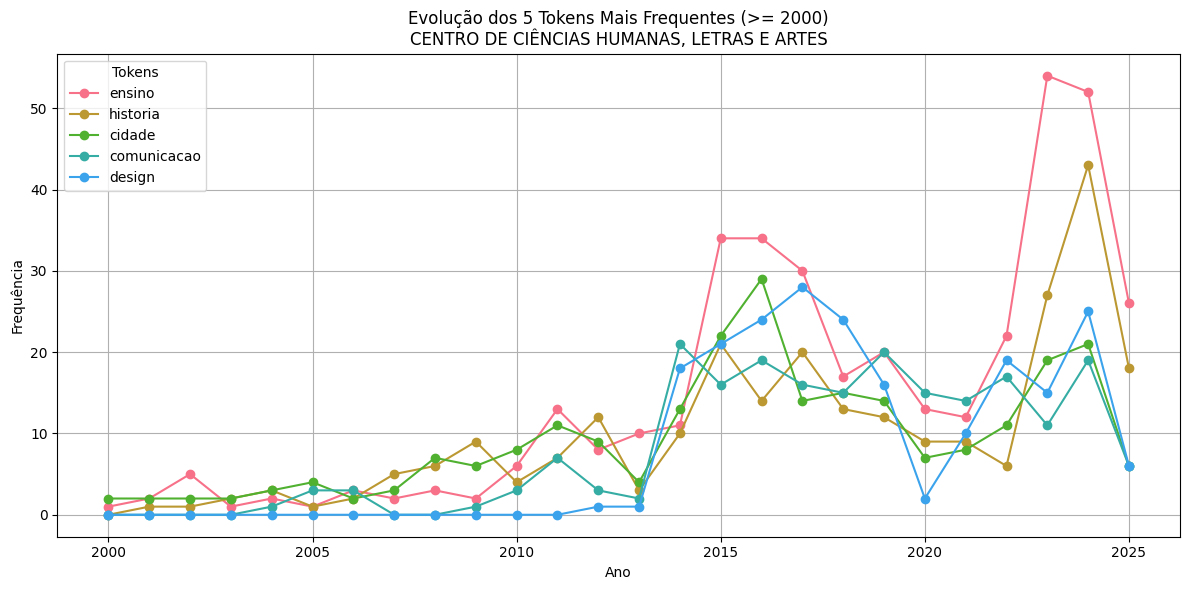

In [42]:
import pandas as pd
import ast
import matplotlib.pyplot as plt

# Load the dataframe
df = pd.read_csv('processamento_textual/dataset_tokens.csv', sep=';')

# Filter for the specific unit and years >= 2000
target_unit = 'CENTRO DE CIÊNCIAS HUMANAS, LETRAS E ARTES'
df_filtered = df[(df['unidade'] == target_unit) & (df['ano'] >= 2000)].copy()

# Convert 'tokens' from string to list
df_filtered['tokens'] = df_filtered['tokens'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

# Explode the tokens
df_exploded = df_filtered.explode('tokens')

# Calculate the top 5 tokens for this filtered data
top_5_tokens = df_exploded['tokens'].value_counts().head(5).index.tolist()
print(f"Top 5 tokens for {target_unit} (>= 2000): {top_5_tokens}")

# Filter for these tokens
df_tokens_filtered = df_exploded[df_exploded['tokens'].isin(top_5_tokens)]

# Group by year and token
df_grouped = df_tokens_filtered.groupby(['ano', 'tokens']).size().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(12, 6))
for token in top_5_tokens:
    if token in df_grouped.columns:
        plt.plot(df_grouped.index, df_grouped[token], label=token, marker='o')

plt.title(f'Evolução dos 5 Tokens Mais Frequentes (>= 2000)\n{target_unit}')
plt.xlabel('Ano')
plt.ylabel('Frequência')
plt.legend(title='Tokens')
plt.grid(True)
plt.tight_layout()
plt.savefig('top_5_tokens_cchla_2000_line_chart.png')